# Topic Clustering for ArXiv Papers

Jupyter Notebook ini dirancang untuk melakukan clustering topik pada dataset arXiv metadata (~5.4 GB, 2.2M+ paper) secara efisien tanpa membuat memori RAM penuh (OOM).

**Metodologi (Two-Stage Representative Clustering):**
1. **Stratified Reservoir Sampling (100.000 paper)**: Membaca dataset dengan generator dan melakukan stratified sampling secara hemat memori (Pass 1 menghitung distribusi, Pass 2 memilih sampel dengan reservoir sampling).
2. **Vectorization & Training**: Mengubah judul dan abstrak sampel menjadi representasi TF-IDF terpisah, lalu menggabungkannya dengan bobot judul lebih besar (2.0). Model KMeans dilatih pada data sampel ini dan disimpan sebagai checkpoint.
3. **Batch Inference & Resume**: Memprediksi klaster sisa 2.1M paper secara bertahap (batch size 100k) dan menyimpannya langsung ke file CSV. Jika proses terhenti, kode akan secara otomatis melanjutkan dari baris terakhir di CSV.

In [1]:
# Imports
import os
import sys
import json
import csv
import random
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Set style untuk plot
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Bagian 1: Data Pipeline & Sampling
Pada bagian ini, kita membuat generator data dan fungsi stratified sampling dengan algoritma Reservoir Sampling yang hemat RAM.

In [2]:
def stream_arxiv_metadata(filepath):
    """Stream arXiv paper metadata from a JSON lines file line by line."""
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                yield json.loads(line)

def get_stratified_sample(filepath, sample_size=100000):
    """Perform memory-efficient two-pass stratified reservoir sampling on arXiv metadata."""
    print("Pass 1: Menghitung distribusi kategori utama...")
    category_counts = defaultdict(int)
    total_docs = 0
    for item in stream_arxiv_metadata(filepath):
        cats = item.get("categories", "")
        if cats:
            primary_cat = cats.split()[0].split(".")[0]
        else:
            primary_cat = "unknown"
        category_counts[primary_cat] += 1
        total_docs += 1
        
    if total_docs == 0:
        return [], [], []

    print(f"Total dokumen ditemukan: {total_docs:,}. Menghitung target sampel...")
    category_targets = {}
    total_allocated = 0
    for cat, count in category_counts.items():
        weight = count / total_docs
        target = max(1, int(weight * sample_size))
        if target > count:
            target = count
        category_targets[cat] = target
        total_allocated += target
        
    # Adjust if total allocated is less than target sample_size due to floor division
    if total_allocated < sample_size and total_docs > total_allocated:
        sorted_cats = sorted(
            category_counts.keys(), 
            key=lambda c: (category_counts[c] / total_docs) * sample_size - category_targets[c], 
            reverse=True
        )
        for cat in sorted_cats:
            if total_allocated >= sample_size:
                break
            if category_targets[cat] < category_counts[cat]:
                category_targets[cat] += 1
                total_allocated += 1

    print("Pass 2: Mengambil sampel menggunakan Reservoir Sampling...")
    category_samples = defaultdict(list)
    category_seen = defaultdict(int)  # running count per category
    
    for item in stream_arxiv_metadata(filepath):
        cats = item.get("categories", "")
        if cats:
            primary_cat = cats.split()[0].split(".")[0]
        else:
            primary_cat = "unknown"
            
        category_seen[primary_cat] += 1
        seen_count = category_seen[primary_cat]
        target_size = category_targets.get(primary_cat, 0)
        
        if target_size == 0:
            continue
            
        sample_list = category_samples[primary_cat]
        if len(sample_list) < target_size:
            sample_list.append(item)
        else:
            r = random.randint(0, seen_count - 1)
            if r < target_size:
                sample_list[r] = item
                
    all_samples = []
    for samples in category_samples.values():
        all_samples.extend(samples)
        
    random.shuffle(all_samples)
    final_samples = all_samples[:sample_size]
    print(f"Selesai mengambil {len(final_samples):,} sampel representatif.")
    
    return (
        [x.get("title", "") for x in final_samples],
        [x.get("abstract", "") for x in final_samples],
        [x.get("categories", "") for x in final_samples]
    )

In [3]:
def test_pipeline():
    dummy_data = [
        {"id": "1", "title": "A", "abstract": "desc A", "categories": "cs.AI"},
        {"id": "2", "title": "B", "abstract": "desc B", "categories": "math.CO"},
        {"id": "3", "title": "C", "abstract": "desc C", "categories": "cs.AI"},
        {"id": "4", "title": "D", "abstract": "desc D", "categories": "hep-ph"}
    ]
    with open("dummy_test.jsonl", "w") as f:
        for item in dummy_data:
            f.write(json.dumps(item) + "\n")
            
    items = list(stream_arxiv_metadata("dummy_test.jsonl"))
    assert len(items) == 4
    assert items[0]["id"] == "1"
    
    t, a, c = get_stratified_sample("dummy_test.jsonl", sample_size=2)
    assert len(t) == 2
    
    if os.path.exists("dummy_test.jsonl"):
        os.remove("dummy_test.jsonl")
    print("Unit Test 1 (Setup & Pipeline) Passed!")

test_pipeline()

Pass 1: Menghitung distribusi kategori utama...
Total dokumen ditemukan: 4. Menghitung target sampel...
Pass 2: Mengambil sampel menggunakan Reservoir Sampling...
Selesai mengambil 2 sampel representatif.
Unit Test 1 (Setup & Pipeline) Passed!


## Bagian 2: Vectorization & Clustering (Training)
Di bagian ini, kita mendefinisikan fungsi untuk melakukan TF-IDF secara terpisah pada Judul dan Abstrak (dengan bobot judul = 2.0), melatih model KMeans, serta menyimpannya ke disk menggunakan `joblib` sebagai checkpoint model.

In [4]:
def fit_and_save_models(titles, abstracts, k, output_dir):
    """Fit TF-IDF vectorizers and KMeans model, then save them using joblib."""
    os.makedirs(output_dir, exist_ok=True)
    
    print("Fitting TF-IDF Vectorizer untuk Title...")
    tfidf_title = TfidfVectorizer(max_features=10000, stop_words="english")
    X_title = tfidf_title.fit_transform(titles)
    
    print("Fitting TF-IDF Vectorizer untuk Abstract...")
    tfidf_abstract = TfidfVectorizer(max_features=25000, stop_words="english")
    X_abstract = tfidf_abstract.fit_transform(abstracts)
    
    # Gabungkan dengan bobot judul 2.0
    X_combined = hstack([X_title * 2.0, X_abstract])
    
    print(f"Melatih KMeans Model dengan K={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_combined)
    
    # Simpan model ke file checkpoint
    joblib.dump(kmeans, os.path.join(output_dir, "kmeans_model.joblib"))
    joblib.dump(tfidf_title, os.path.join(output_dir, "tfidf_title.joblib"))
    joblib.dump(tfidf_abstract, os.path.join(output_dir, "tfidf_abstract.joblib"))
    print(f"Model berhasil dilatih dan disimpan di folder '{output_dir}'.")
    
    return kmeans, tfidf_title, tfidf_abstract

def load_models(output_dir):
    """Load model checkpoints if they exist, otherwise return None."""
    kmeans_path = os.path.join(output_dir, "kmeans_model.joblib")
    tfidf_title_path = os.path.join(output_dir, "tfidf_title.joblib")
    tfidf_abstract_path = os.path.join(output_dir, "tfidf_abstract.joblib")
    
    if os.path.exists(kmeans_path) and os.path.exists(tfidf_title_path) and os.path.exists(tfidf_abstract_path):
        kmeans = joblib.load(kmeans_path)
        tfidf_title = joblib.load(tfidf_title_path)
        tfidf_abstract = joblib.load(tfidf_abstract_path)
        return kmeans, tfidf_title, tfidf_abstract
    return None

In [5]:
def test_model_training():
    titles = ["Quantum computing", "Graph theory and networks", "Deep reinforcement learning"]
    abstracts = [
        "We discuss quantum bits and gates.",
        "We analyze sparse graphs and trees.",
        "We study neural networks for deep learning."
    ]
    
    kmeans, tfidf_title, tfidf_abstract = fit_and_save_models(
        titles, abstracts, k=2, output_dir="test_checkpoints"
    )
    
    assert kmeans is not None
    assert tfidf_title is not None
    assert tfidf_abstract is not None
    
    loaded = load_models("test_checkpoints")
    assert loaded is not None
    assert loaded[0].n_clusters == 2
    
    for f in ["kmeans_model.joblib", "tfidf_title.joblib", "tfidf_abstract.joblib"]:
        path = os.path.join("test_checkpoints", f)
        if os.path.exists(path):
            os.remove(path)
    if os.path.exists("test_checkpoints"):
        os.rmdir("test_checkpoints")
    print("Unit Test 2 (Vectorization & Training) Passed!")

test_model_training()

Fitting TF-IDF Vectorizer untuk Title...
Fitting TF-IDF Vectorizer untuk Abstract...
Melatih KMeans Model dengan K=2...
Model berhasil dilatih dan disimpan di folder 'test_checkpoints'.
Unit Test 2 (Vectorization & Training) Passed!


## Bagian 3: Batch Inference & Resuming Checkpoint
Di bagian ini, kita menambahkan fungsi untuk melakukan prediksi klaster pada sisa data secara bertahap (*batch*). Sistem akan otomatis mendeteksi baris yang sudah ditulis pada file CSV hasil untuk melakukan *resume* jika terhenti di tengah jalan.

In [6]:
def run_batch_inference_with_checkpoint(filepath, output_csv, tfidf_title, tfidf_abstract, kmeans, batch_size=100000):
    """Run batch predictions on remaining arXiv metadata with resume checkpointing."""
    already_processed = set()
    file_exists = os.path.exists(output_csv)
    
    # Hitung data yang sudah sukses diproses sebelumnya
    if file_exists:
        print(f"File hasil '{output_csv}' ditemukan. Membaca indeks yang sudah diproses...")
        try:
            with open(output_csv, "r", encoding="utf-8") as f:
                reader = csv.reader(f)
                header = next(reader, None)
                if header:
                    for row in reader:
                        if row:
                            already_processed.add(row[0])  # Kolom 0 adalah paper_id
            print(f"Ditemukan {len(already_processed):,} paper yang sudah diproses sebelumnya.")
        except Exception as e:
            print(f"Error membaca file hasil: {e}. Memulai dari awal...")
            
    mode = "a" if file_exists else "w"
    
    # Tulis header jika file baru dibuat
    if not file_exists:
        with open(output_csv, mode, newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["id", "cluster", "title", "abstract", "categories"])
            
    batch_ids = []
    batch_titles = []
    batch_abstracts = []
    batch_categories = []
    
    processed_count = 0
    
    print("Memulai streaming data untuk prediksi...")
    for item in stream_arxiv_metadata(filepath):
        paper_id = item.get("id", "")
        if paper_id in already_processed:
            continue
            
        batch_ids.append(paper_id)
        batch_titles.append(item.get("title", ""))
        batch_abstracts.append(item.get("abstract", ""))
        batch_categories.append(item.get("categories", ""))
        
        if len(batch_ids) >= batch_size:
            _write_batch(batch_ids, batch_titles, batch_abstracts, batch_categories, 
                         tfidf_title, tfidf_abstract, kmeans, output_csv)
            processed_count += len(batch_ids)
            print(f"Progres: Berhasil memproses {processed_count:,} paper baru.")
            batch_ids, batch_titles, batch_abstracts, batch_categories = [], [], [], []
            
    if batch_ids:
        _write_batch(batch_ids, batch_titles, batch_abstracts, batch_categories, 
                     tfidf_title, tfidf_abstract, kmeans, output_csv)
        processed_count += len(batch_ids)
        
    return processed_count

def _write_batch(ids, titles, abstracts, categories, tfidf_title, tfidf_abstract, kmeans, output_csv):
    # Vectorization & Transform
    X_t = tfidf_title.transform(titles)
    X_a = tfidf_abstract.transform(abstracts)
    X_comb = hstack([X_t * 2.0, X_a])
    
    # Predict clusters
    preds = kmeans.predict(X_comb)
    
    # Tulis ke file hasil (append mode)
    with open(output_csv, "a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        for i in range(len(ids)):
            clean_title = titles[i].replace("\n", " ").strip()
            clean_abstract = abstracts[i].replace("\n", " ").strip()
            writer.writerow([ids[i], preds[i], clean_title, clean_abstract, categories[i]])

In [7]:
def test_resume():
    data = [
        {"id": "1", "title": "Quantum qubits", "abstract": "gates and superposition", "categories": "quant-ph"},
        {"id": "2", "title": "Graph colorings", "abstract": "trees and vertices", "categories": "math.CO"},
        {"id": "3", "title": "Deep learning NLP", "abstract": "networks and transformers", "categories": "cs.CL"},
        {"id": "4", "title": "Cosmology inflation", "abstract": "dark energy and universe", "categories": "astro-ph"},
    ]
    json_path = "test_data.jsonl"
    with open(json_path, "w") as f:
        for item in data:
            f.write(json.dumps(item) + "\n")
            
    titles = [x["title"] for x in data]
    abstracts = [x["abstract"] for x in data]
    kmeans, tf_t, tf_a = fit_and_save_models(titles, abstracts, k=2, output_dir="test_checkpoints")
    
    csv_path = "test_predictions.csv"
    if os.path.exists(csv_path):
        os.remove(csv_path)
        
    # Run 1: Memproses data awal
    count1 = run_batch_inference_with_checkpoint(json_path, csv_path, tf_t, tf_a, kmeans, batch_size=2)
    assert count1 == 4
    
    # Tambah data baru ke JSONL
    new_data = [
        {"id": "5", "title": "String theory", "abstract": "dimensions and supersymmetry", "categories": "hep-th"}
    ]
    with open(json_path, "a") as f:
        for item in new_data:
            f.write(json.dumps(item) + "\n")
            
    # Run 2: Seharusnya mendeteksi 4 data lama dan hanya memproses 1 data baru
    count2 = run_batch_inference_with_checkpoint(json_path, csv_path, tf_t, tf_a, kmeans, batch_size=2)
    assert count2 == 1
    
    # Cleanup
    for f in [json_path, csv_path]:
        if os.path.exists(f):
            os.remove(f)
    for f in ["kmeans_model.joblib", "tfidf_title.joblib", "tfidf_abstract.joblib"]:
        path = os.path.join("test_checkpoints", f)
        if os.path.exists(path):
            os.remove(path)
    if os.path.exists("test_checkpoints"):
        os.rmdir("test_checkpoints")
    print("Unit Test 3 (Batch Inference & Resume) Passed!")

test_resume()

Fitting TF-IDF Vectorizer untuk Title...
Fitting TF-IDF Vectorizer untuk Abstract...
Melatih KMeans Model dengan K=2...
Model berhasil dilatih dan disimpan di folder 'test_checkpoints'.
Memulai streaming data untuk prediksi...
Progres: Berhasil memproses 2 paper baru.
Progres: Berhasil memproses 4 paper baru.
File hasil 'test_predictions.csv' ditemukan. Membaca indeks yang sudah diproses...
Ditemukan 4 paper yang sudah diproses sebelumnya.
Memulai streaming data untuk prediksi...
Unit Test 3 (Batch Inference & Resume) Passed!


## Bagian 4: Menentukan Jumlah Klaster (Elbow Method)
Di bawah ini, kita akan menjalankan K-Means dengan beberapa nilai K kandidat pada sub-sampel kecil (10.000 paper) untuk memplot grafik inersia (Elbow Method). Ini membantu mengonfirmasi K optimal secara visual.

Mengambil 10.000 paper untuk analisis Elbow...
Pass 1: Menghitung distribusi kategori utama...
Total dokumen ditemukan: 3,148,882. Menghitung target sampel...
Pass 2: Mengambil sampel menggunakan Reservoir Sampling...
Selesai mengambil 10,000 sampel representatif.
Menghitung inersia untuk K=5...
Menghitung inersia untuk K=10...
Menghitung inersia untuk K=15...
Menghitung inersia untuk K=20...


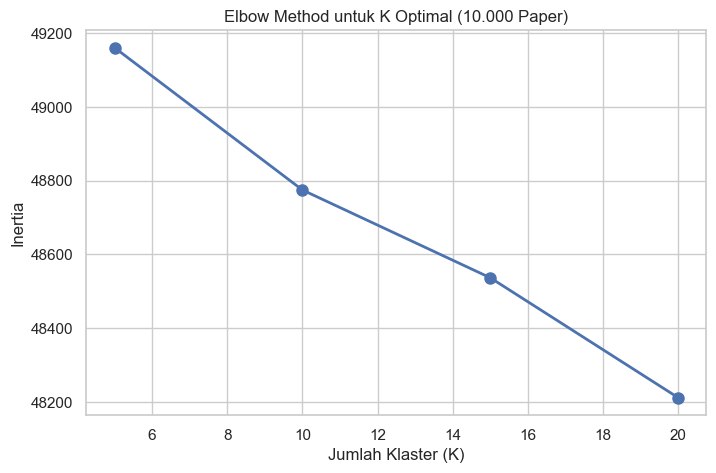

In [8]:
# Jalankan ini untuk menentukan K optimal
DATASET_PATH = "../arxiv-metadata-oai-snapshot.json"

if os.path.exists(DATASET_PATH):
    print("Mengambil 10.000 paper untuk analisis Elbow...")
    t_elbow, a_elbow, _ = get_stratified_sample(DATASET_PATH, sample_size=10000)
    
    vectorizer_t = TfidfVectorizer(max_features=5000, stop_words="english")
    vectorizer_a = TfidfVectorizer(max_features=10000, stop_words="english")
    
    X_t = vectorizer_t.fit_transform(t_elbow)
    X_a = vectorizer_a.fit_transform(a_elbow)
    X_comb = hstack([X_t * 2.0, X_a])
    
    inertias = []
    k_candidates = [5, 10, 15, 20]
    for k in k_candidates:
        print(f"Menghitung inersia untuk K={k}...")
        km = KMeans(n_clusters=k, random_state=42, n_init=5)
        km.fit(X_comb)
        inertias.append(km.inertia_)
        
    plt.figure(figsize=(8, 5))
    plt.plot(k_candidates, inertias, "bo-", linewidth=2, markersize=8)
    plt.xlabel("Jumlah Klaster (K)")
    plt.ylabel("Inertia")
    plt.title("Elbow Method untuk K Optimal (10.000 Paper)")
    plt.grid(True)
    plt.show()
else:
    print(f"File dataset tidak ditemukan di '{DATASET_PATH}'. Lewati visualisasi Elbow.")

## Bagian 5: Eksplorasi Model & Training Utama
Di bawah ini adalah tempat kita mengonfigurasi parameter utama untuk melatih model clustering pada 100.000 paper representatif. Jika model checkpoint sudah ada di disk, model tersebut akan langsung dimuat secara instan.

In [9]:
# Konfigurasi Utama
MODEL_DIR = "checkpoints"
SAMPLE_SIZE = 100000
K_CLUSTERS = 15

loaded = load_models(MODEL_DIR)
if loaded:
    print("Checkpoint model ditemukan! Memuat model dari disk...")
    kmeans, tfidf_title, tfidf_abstract = loaded
else:
    if os.path.exists(DATASET_PATH):
        print(f"Melakukan stratified sampling sebanyak {SAMPLE_SIZE:,} paper...")
        titles, abstracts, categories = get_stratified_sample(DATASET_PATH, sample_size=SAMPLE_SIZE)
        
        print(f"Melatih model KMeans utama dengan K={K_CLUSTERS}...")
        kmeans, tfidf_title, tfidf_abstract = fit_and_save_models(
            titles, abstracts, k=K_CLUSTERS, output_dir=MODEL_DIR
        )
    else:
        print(f"File dataset tidak ditemukan di '{DATASET_PATH}'. Silakan pastikan file ada di path tersebut.")

Checkpoint model ditemukan! Memuat model dari disk...


### Visualisasi Kata Kunci Teratas per Klaster
Menampilkan kata kunci dengan bobot tertinggi untuk Judul dan Abstrak pada setiap klaster. Ini membantu kita memahami topik yang diwakili oleh masing-masing klaster.

In [10]:
if 'kmeans' in locals() and kmeans is not None:
    vocab_t = tfidf_title.get_feature_names_out()
    vocab_a = tfidf_abstract.get_feature_names_out()
    centroids = kmeans.cluster_centers_
    
    len_t = len(vocab_t)
    
    for cluster_id in range(K_CLUSTERS):
        centroid = centroids[cluster_id]
        centroid_t = centroid[:len_t] / 2.0  # Kembalikan skala bobot title
        centroid_a = centroid[len_t:]
        
        top_t_indices = np.argsort(centroid_t)[-10:][::-1]
        top_a_indices = np.argsort(centroid_a)[-10:][::-1]
        
        top_t_words = [vocab_t[i] for i in top_t_indices]
        top_a_words = [vocab_a[i] for i in top_a_indices]
        
        print(f"\n================ KLASTER {cluster_id:02d} ================")
        print(f"Top 10 Judul  : {', '.join(top_t_words)}")
        print(f"Top 10 Abstrak: {', '.join(top_a_words)}")
else:
    print("Model KMeans belum dilatih.")


================ KLASTER 00 ================
Top 10 Judul  : based, data, multi, using, detection, image, analysis, network, framework, generation
Top 10 Abstrak: data, based, model, performance, models, methods, method, image, training, propose

================ KLASTER 01 ================
Top 10 Judul  : equations, functions, problem, groups, spaces, equation, algebras, theorem, solutions, operators
Top 10 Abstrak: equation, equations, solutions, functions, spaces, mathbb, prove, group, problem, space

================ KLASTER 02 ================
Top 10 Judul  : dynamics, molecular, quantum, model, simulations, non, systems, time, stochastic, fluid
Top 10 Abstrak: dynamics, time, model, quantum, dynamical, systems, non, energy, study, simulations

================ KLASTER 03 ================
Top 10 Judul  : models, language, large, vision, diffusion, using, based, data, generative, reasoning
Top 10 Abstrak: models, model, language, llms, data, large, based, performance, reasoning, t

## Bagian 6: Eksekusi Prediksi Massal & Evaluasi Hasil
Jalankan sel ini untuk memulai proses prediksi klaster pada seluruh 2.2 juta paper di arXiv. Jika terhenti, jalankan kembali sel ini untuk melanjutkan dari paper terakhir.

In [11]:
OUTPUT_CSV = "arxiv_clustered_results.csv"

if 'kmeans' in locals() and kmeans is not None and os.path.exists(DATASET_PATH):
    print("Memulai batch inference pada seluruh dataset...")
    new_processed = run_batch_inference_with_checkpoint(
        filepath=DATASET_PATH,
        output_csv=OUTPUT_CSV,
        tfidf_title=tfidf_title,
        tfidf_abstract=tfidf_abstract,
        kmeans=kmeans,
        batch_size=100000
    )
    print(f"\nProses selesai! Jumlah paper baru yang berhasil diproses: {new_processed:,}")
else:
    print("Model belum dilatih atau dataset tidak ditemukan.")

Memulai batch inference pada seluruh dataset...
File hasil 'arxiv_clustered_results.csv' ditemukan. Membaca indeks yang sudah diproses...
Ditemukan 3,100,419 paper yang sudah diproses sebelumnya.
Memulai streaming data untuk prediksi...

Proses selesai! Jumlah paper baru yang berhasil diproses: 48,373


### Analisis Distribusi Klaster & Profiling Bidang Akademis arXiv asli
Membaca file CSV hasil prediksi untuk memplot penyebaran paper di setiap klaster dan menampilkan kategori arXiv asli yang paling dominan di tiap klaster untuk memvalidasi relevansi pengelompokan.

Membaca file hasil prediksi...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_36644\3375503119.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_res, x="cluster", palette="viridis")


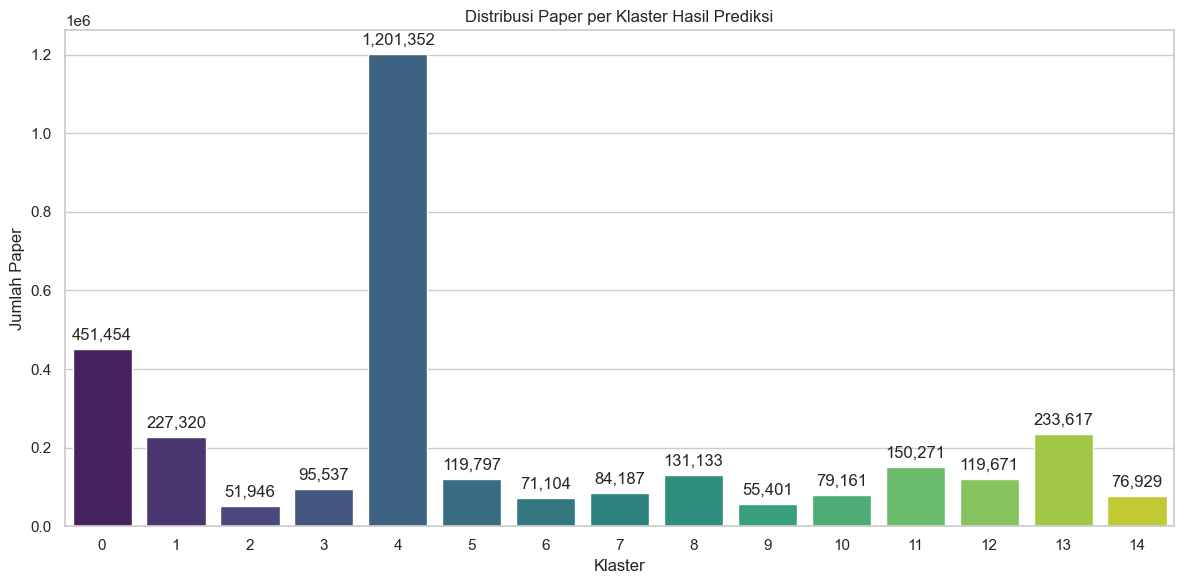


PROFILING KATEGORI ARXIV ASLI PER KLASTER:

Klaster 00 - Top 5 Kategori arXiv Asli:
  1. cs.CV: 122,598 paper (27.16%)
  2. cs.LG: 97,899 paper (21.69%)
  3. cs.AI: 89,458 paper (19.82%)
  4. cs.CL: 60,829 paper (13.47%)
  5. cs.RO: 28,484 paper (6.31%)

Klaster 01 - Top 5 Kategori arXiv Asli:
  1. math.AP: 39,914 paper (17.56%)
  2. math.MP: 19,823 paper (8.72%)
  3. math-ph: 19,823 paper (8.72%)
  4. math.FA: 18,719 paper (8.23%)
  5. math.DG: 17,798 paper (7.83%)

Klaster 02 - Top 5 Kategori arXiv Asli:
  1. quant-ph: 6,032 paper (11.61%)
  2. cond-mat.stat-mech: 5,488 paper (10.56%)
  3. cond-mat.soft: 3,942 paper (7.59%)
  4. cond-mat.mtrl-sci: 3,529 paper (6.79%)
  5. math.DS: 3,230 paper (6.22%)

Klaster 03 - Top 5 Kategori arXiv Asli:
  1. cs.AI: 21,442 paper (22.44%)
  2. cs.CL: 21,274 paper (22.27%)
  3. cs.LG: 20,921 paper (21.90%)
  4. cs.CV: 13,815 paper (14.46%)
  5. hep-th: 5,734 paper (6.00%)

Klaster 04 - Top 5 Kategori arXiv Asli:
  1. hep-ph: 116,050 paper (9.66%)
 

In [12]:
if os.path.exists(OUTPUT_CSV):
    print("Membaca file hasil prediksi...")
    df_res = pd.read_csv(OUTPUT_CSV, dtype={'id': str}, low_memory=False)
    
    # Plot Distribusi Klaster
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(data=df_res, x="cluster", palette="viridis")
    plt.title("Distribusi Paper per Klaster Hasil Prediksi")
    plt.xlabel("Klaster")
    plt.ylabel("Jumlah Paper")
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')
    plt.tight_layout()
    plt.show()
    
    # Cari kategori arXiv dominan per klaster
    print("\nPROFILING KATEGORI ARXIV ASLI PER KLASTER:")
    for cid in sorted(df_res["cluster"].unique()):
        sub_df = df_res[df_res["cluster"] == cid]
        cats = sub_df["categories"].dropna().str.split().explode()
        top_cats = cats.value_counts().head(5)
        print(f"\nKlaster {cid:02d} - Top 5 Kategori arXiv Asli:")
        for rank, (cat, val) in enumerate(top_cats.items(), 1):
            percentage = (val / len(sub_df)) * 100
            print(f"  {rank}. {cat}: {val:,} paper ({percentage:.2f}%)")
else:
    print(f"File hasil '{OUTPUT_CSV}' belum terbentuk. Selesaikan prediksi massal terlebih dahulu.")